Saved  /Users/jakobwerkgarner/code/mt_dsnow/compare_snowpack_runs/SP_inout_data/LWD_all/station_map.png


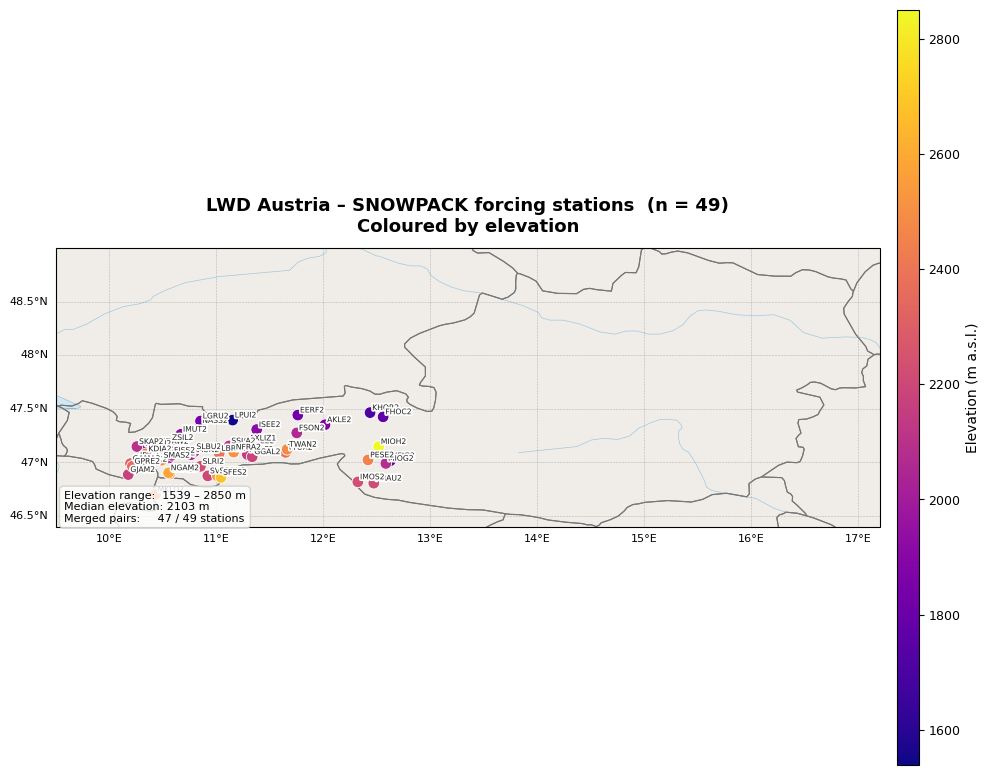

In [12]:
"""
Plot LWD station locations on a map of Austria, coloured by elevation.
The map extent covers all of Austria with an undistorted aspect ratio.
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ── Load data ─────────────────────────────────────────────────────────────────
CSV_PATH   = "/Users/jakobwerkgarner/code/mt_dsnow/compare_snowpack_runs/SP_inout_data/LWD_all/station_summary.csv"
OUT_PATH   = "/Users/jakobwerkgarner/code/mt_dsnow/compare_snowpack_runs/SP_inout_data/LWD_all/station_map.png"

df = pd.read_csv(CSV_PATH, sep=";", decimal=",", encoding="latin-1")
df["latitude"]  = pd.to_numeric(df["latitude"],  errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["altitude_m"]= pd.to_numeric(df["altitude_m"],errors="coerce")
df = df.dropna(subset=["latitude", "longitude", "altitude_m"])

# ── Map extents – full Austria (no automatic zoom) ────────────────────────────
lon_min, lon_max = 9.5, 17.2
lat_min, lat_max = 46.4, 49.0
lon_range = lon_max - lon_min
lat_range = lat_max - lat_min

# Compute central latitude for correcting aspect ratio (PlateCarree)
central_lat = (lat_min + lat_max) / 2
# Factor to adjust for longitude convergence: cos(latitude)
aspect_factor = np.cos(np.radians(central_lat))

# Desired figure height (inches) – change as you like
fig_height = 10
# Correct width so that 1° longitude = 1° latitude at central latitude
fig_width = 10
# ── Colour scale ──────────────────────────────────────────────────────────────
cmap  = plt.get_cmap("plasma")
norm  = Normalize(vmin=df["altitude_m"].min(), vmax=df["altitude_m"].max())

# ── Figure with correct aspect ratio ──────────────────────────────────────────
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(
    figsize=(fig_width, fig_height),
    subplot_kw={"projection": proj},
)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# Background features (50m resolution – bundled with cartopy)
RES = "50m"
ax.add_feature(cfeature.NaturalEarthFeature("physical", "land",   RES,
               facecolor="#f0ede8"), zorder=0)
ax.add_feature(cfeature.NaturalEarthFeature("physical", "ocean",  RES,
               facecolor="#d0e8f5"), zorder=0)
ax.add_feature(cfeature.NaturalEarthFeature("physical", "lakes",  RES,
               facecolor="#d0e8f5", edgecolor="#90b8d0", linewidth=0.4), zorder=1)
ax.add_feature(cfeature.NaturalEarthFeature("physical", "rivers_lake_centerlines", RES,
               facecolor="none", edgecolor="#a0c8e0", linewidth=0.5), zorder=1)
ax.add_feature(cfeature.NaturalEarthFeature("cultural", "admin_0_countries", RES,
               facecolor="none", edgecolor="#777777", linewidth=0.8), zorder=2)
ax.add_feature(cfeature.NaturalEarthFeature("cultural", "admin_1_states_provinces", RES,
               facecolor="none", edgecolor="#aaaaaa", linewidth=0.4), zorder=2)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.4, color="gray",
    alpha=0.5, linestyle="--", zorder=3,
)
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}

# ── Scatter stations ──────────────────────────────────────────────────────────
sc = ax.scatter(
    df["longitude"], df["latitude"],
    c=df["altitude_m"], cmap=cmap, norm=norm,
    s=70, zorder=5, edgecolors="white", linewidths=0.6,
    transform=proj,
)

# Station labels (with white halo)
outline = [pe.withStroke(linewidth=2.5, foreground="white")]
for _, row in df.iterrows():
    ax.text(
        row["longitude"] + 0.02, row["latitude"] + 0.015,
        row["station_id"],
        fontsize=5.5, color="#222222",
        path_effects=outline,
        transform=proj, zorder=6,
        ha="left", va="bottom",
    )

# ── Colour bar ────────────────────────────────────────────────────────────────
sm  = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical",
                    fraction=0.025, pad=0.02, aspect=35)
cbar.set_label("Elevation (m a.s.l.)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ── Titles and decorations ────────────────────────────────────────────────────
ax.set_title(
    f"LWD Austria – SNOWPACK forcing stations  (n = {len(df)})\n"
    "Coloured by elevation",
    fontsize=13, fontweight="bold", pad=12,
)

# Statistics box
stats = (
    f"Elevation range:  {df['altitude_m'].min():.0f} – {df['altitude_m'].max():.0f} m\n"
    f"Median elevation: {df['altitude_m'].median():.0f} m\n"
    f"Merged pairs:     {df['was_merged'].eq('yes').sum()} / {len(df)} stations"
)
ax.text(
    0.01, 0.01, stats,
    transform=ax.transAxes,
    fontsize=8, va="bottom", ha="left",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8, edgecolor="#cccccc"),
    zorder=7,
)

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=180, bbox_inches="tight")
print(f"Saved  {OUT_PATH}")
plt.show()